In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import yfinance as yf

# Step 1: Download NVIDIA stock data (Feature Selection)
data = yf.download('NVDA', start='2018-01-01', end='2023-01-01')
data = data[['Close', 'Open', 'High', 'Low', 'Volume']]

[*********************100%***********************]  1 of 1 completed


#Data Preprocessing

In [17]:
# Step 2: Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


#Feature Engineering

In [20]:
# Step 3: Prepare sequences
def create_sequences_multivariate(data, n_timesteps, target_column_index):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:i + n_timesteps])
        y.append(data[i + n_timesteps, target_column_index])
    return np.array(X), np.array(y)

n_timesteps = 7
n_features = data_scaled.shape[1]
target_column_index = 0  # 'Close' is the target

X_train, y_train = create_sequences_multivariate(train_data_final, n_timesteps, target_column_index)
X_valid, y_valid = create_sequences_multivariate(valid_data, n_timesteps, target_column_index)
X_test, y_test = create_sequences_multivariate(test_data, n_timesteps, target_column_index)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

#Train Test Split

In [18]:
# Step 4: Split Data
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

train_valid_size = int(len(train_data) * 0.8)
train_data_final = train_data[:train_valid_size]
valid_data = train_data[train_valid_size:]

#Defining Neural Network Architecture

In [21]:
# Step 5: Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=1, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Use the last time step
        return out

#Trainning Loop

In [27]:
# Step 6: Train the Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size=n_features, hidden_size=50, num_layers=1, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses, valid_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_losses.append(train_loss / len(train_loader.dataset))

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            valid_loss += loss.item() * X_batch.size(0)

    valid_losses.append(valid_loss / len(valid_loader.dataset))
    print(f'Epoch {epoch+1}, Train Loss: {train_losses[-1]:.6f}, Valid Loss: {valid_losses[-1]:.6f}')

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1, Train Loss: 0.009497, Valid Loss: 0.098247
Epoch 2, Train Loss: 0.001560, Valid Loss: 0.015623
Epoch 3, Train Loss: 0.000297, Valid Loss: 0.002943
Epoch 4, Train Loss: 0.000159, Valid Loss: 0.001174
Epoch 5, Train Loss: 0.000131, Valid Loss: 0.000998
Epoch 6, Train Loss: 0.000133, Valid Loss: 0.001033
Epoch 7, Train Loss: 0.000128, Valid Loss: 0.001675
Epoch 8, Train Loss: 0.000130, Valid Loss: 0.002094
Epoch 9, Train Loss: 0.000127, Valid Loss: 0.001593
Epoch 10, Train Loss: 0.000124, Valid Loss: 0.001981
Epoch 11, Train Loss: 0.000121, Valid Loss: 0.003216
Epoch 12, Train Loss: 0.000121, Valid Loss: 0.002430
Epoch 13, Train Loss: 0.000128, Valid Loss: 0.005110
Epoch 14, Train Loss: 0.000130, Valid Loss: 0.002439
Epoch 15, Train Loss: 0.000116, Valid Loss: 0.002425
Epoch 16, Train Loss: 0.000118, Valid Loss: 0.002440
Epoch 17, Train Loss: 0.000129, Valid Loss: 0.002758
Epoch 18, Train Loss: 0.000119, Valid Loss: 0.003146
Epoch 19, Train Loss: 0.000134, Valid Loss: 0.002705
Ep

#Evaluate the Model

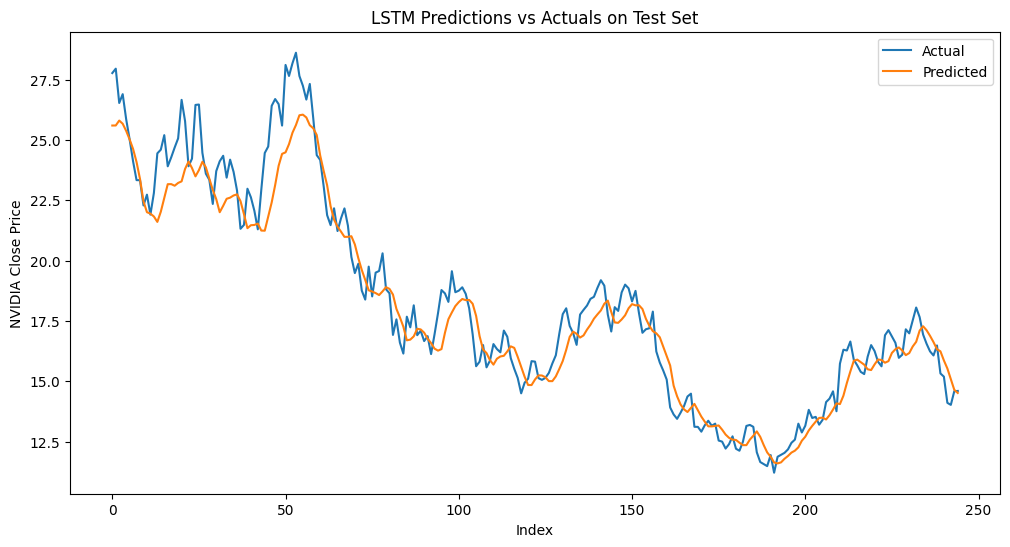

In [23]:
# Step 7: Evaluate and Visualize
model.eval()
with torch.no_grad():
    test_preds = model(X_test.to(device)).cpu().numpy()
    test_actuals = y_test.numpy()

def denormalize(data, scaler, index):
    full_data = np.zeros((len(data), scaler.n_features_in_))
    full_data[:, index] = data[:, 0]
    return scaler.inverse_transform(full_data)[:, index]

test_preds_denorm = denormalize(test_preds.reshape(-1, 1), scaler, target_column_index)
test_actuals_denorm = denormalize(test_actuals.reshape(-1, 1), scaler, target_column_index)

plt.figure(figsize=(12, 6))
plt.plot(test_actuals_denorm, label='Actual')
plt.plot(test_preds_denorm, label='Predicted')
plt.title('LSTM Predictions vs Actuals on Test Set')
plt.xlabel('Index')
plt.ylabel('NVIDIA Close Price')
plt.legend()
plt.show()

#Metrics to Evaluate the Model (RMSE)

In [28]:
rmse = np.sqrt(mean_squared_error(test_actuals_denorm, test_preds_denorm))
print(f"RMSE: {rmse:.4f}")

RMSE: 1.1581


In [24]:

# Step 8: Save the Model
torch.save(model.state_dict(), 'nvda_lstm_model.pth')